# Characterising Networks

In this notebook, we will explore common approaches that are used to characterise and study a new network, using two different examples.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline

## Example 1

As our first example of characterising a network, we will explore the  “Zachary's Karate Club” *friendship network*. This data comes from a study of a university karate club in the United States during the 1970s, where the researchers recorded friendships among 34 club members based on observed interactions.

We can use the version of the Karate Club network that is bundled with the NetworkX Python package. This is an **undirected network**, as the friendships recorded in the study are treated as mutual rather than one way. So an edge between two nodes in this network has no direction, as it simply shows the existence of a friendship.

In [2]:
g = nx.karate_club_graph()
# check the type of the network
print(type(g))

<class 'networkx.classes.graph.Graph'>


The most basic characterisation we might perform would be simply to count the number of nodes and edges:

In [3]:
print(f"Network has {g.number_of_nodes()} nodes and {g.number_of_edges()} edges")

Network has 34 nodes and 78 edges


Produce a simple network diagram for this network using the `nx.draw()` function:

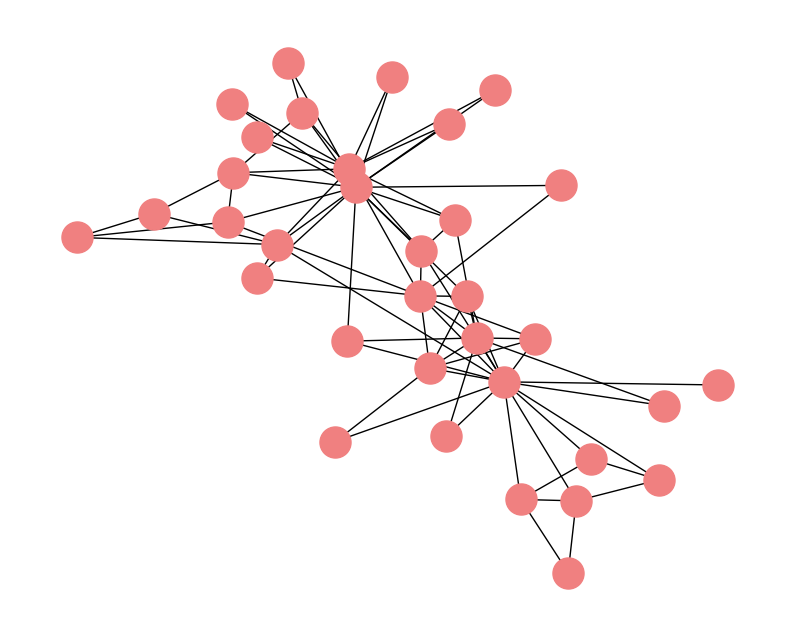

In [4]:
# specify the size of the figure
plt.figure(figsize=(10, 8))
# draw the network diagram
nx.draw_networkx(g, 
                 with_labels=False, 
                 node_size=500, 
                 node_color="lightcoral")
plt.axis("off")
plt.show()

We often look at the level of connectivity in a network - i.e. its **density**. A dense network is one where the number of edges is close to the maximum possible number of edges. Network density is calculated as the ratio of actual edges to the maximum possible edges in the network.

In [5]:
density = nx.density(g)
print(f"Density of the graph: {density:.4f}")

Density of the graph: 0.1390


## Example 2

As our second example, we will load load a small network representing the relations between a set of users on the *LinkedIn* platform. This is an **undirected network**, since a standard connection on this platform is always mutual. Each edge signifies that two users (nodes) are connected on the platform.

The network is stored in the XML-based GEXF format, which NetworkX can read natively using the `nx.read_gexf()` function:

In [ ]:
# load the network from the specified file
g = nx.read_gexf("linkedin25.gexf")
# check the network type
print(type(g))

Check the size of the network:

In [ ]:
print(f"Network has {g.number_of_nodes()} nodes and {g.number_of_edges()} edges")

Draw a simple network diagram for this network:

In [ ]:
# specify the size of the figure
plt.figure(figsize=(11, 9))
# draw the network diagram
nx.draw_networkx(g, 
                 with_labels=True, 
                 node_size=800, 
                 node_color="lightblue")
plt.axis("off")
plt.show()

### Density and Paths

We often look at the level of connectivity in a network - i.e. its **density**. A dense network is one where the number of edges is close to the maximum possible number of edges. Network density is calculated as the ratio of actual edges to the maximum possible edges in the network.

In [ ]:
density = nx.density(g)
print(f"Density of the graph: {density:.4f}")

We can also check if the network is **connected** - i.e. is there a path between every pair of nodes?

In [ ]:
nx.is_connected(g)

A **path** is a sequence of nodes and edges which connect one node to another. A graph is connected if every pair of nodes is joined at least by one path. We can check if two nodes are connected in the specified network using the `nx.has_path()` function:

In [ ]:
nx.has_path(g, "Eric Smith", "Tina Davis")

The length of a path is the number of edges it crosses. The **shortest path** between two nodes in a network is the path with the minimum number of edges.

We can find the shortest path between two nodes in the specified network using the `nx.shortest_path()` function:

In [ ]:
nx.shortest_path(g, "Eric Smith", "Tina Davis")

In [ ]:
nx.shortest_path(g, "Eric Smith", "Maria Collins")

The **distance** between two nodes in a network is the length of the shortest path between them (i.e. number of edges crossed).

In [ ]:
nx.shortest_path_length(g, "Eric Smith", "Tina Davis")

In [ ]:
nx.shortest_path_length(g, "Eric Smith", "Maria Collins")

The **diameter** of a network is the length of the longest shortest path between any pair of nodes in the network.

In [ ]:
nx.diameter(g)

### Network Components

Currently, the network consists of one single, large **component** - i.e. the network is **connected**.

In [ ]:
# how many components?
nx.number_connected_components(g)

In [ ]:
# alternatively, check if the network connected? i.e. does it just have one component?
nx.is_connected(g)

However, if we were to remove certain nodes from the networks, the network would start to split up:

In [ ]:
# remove the node from the network with the specifed ID
g.remove_node("Eric Smith")

The network now consists of two distinct **connected components**. We can iterate over those components using the function `connected_components()`:

In [ ]:
nx.number_connected_components(g)

In [ ]:
# display the nodes in each component
components = nx.connected_components(g)
for i, comp in enumerate(components):
    print(f"- Component {i+1} has {len(comp)} nodes:")
    print(comp)

We can see the split visually too by drawing the updated network diagram:

In [ ]:
# specify the size of the figure
plt.figure(figsize=(11, 9))
# draw the network diagram
nx.draw_networkx(g, 
                 with_labels=True, 
                 node_size=800, 
                 node_color="lightblue")
plt.axis("off")
plt.show()